# Rock Game Prototype Checkpoint Walkthrough

This notebook runs the split-module prototype flow using `GameMaster`.

Checkpoints covered:
- create a playable game
- inspect starter rocks and market pods
- queue parents and advance a generation
- buy potions
- buy a defined-trait rock
- buy a market pod and keep a child
- serialize and reload the game
- render one rock, rock grids, and lineage trees
- build a larger multi-generation tree smoke check

In [12]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "Develepor_X":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import Rock_Genetics.rock_genetic_helper as genetics
from Rock_GameState.rock_game_state_helper import GameMaster
from Rock_Serialization.rock_serialization_helper import game_to_json_string, game_from_json_string
from Rock_Drawing.rock_draw_machine import draw_rock
from Rock_Drawing.rock_lineage_drawing_helper import TreeDrawer, show_rocks as show_rock_grid
import matplotlib.pyplot as plt

print(f"Loaded project from: {PROJECT_ROOT}")

Loaded project from: c:\Users\xavie\Desktop\rock_game


## Helper Display Functions

In [13]:
def show_status(game, label="Game status"):
    print(f"\n=== {label} ===")
    for key, value in game.update_display().items():
        if key == "events":
            continue
        print(f"{key}: {value}")
    print("recent events:")
    for event in game.events[-6:]:
        print(f"- {event}")


def list_rocks(game, label="Rocks"):
    print(f"\n=== {label} ===")
    for line in game.show_rocks():
        print(line)


def show_market(game, label="Market pods"):
    print(f"\n=== {label} ===")
    for offer in game.market_pods:
        used = "used" if offer.used else "available"
        print(f"{offer.offer_id}: {offer.name} | ${offer.price} | {used} | {offer.tagline}")

## Checkpoint 1: Create A Playable Game

In [14]:
game = GameMaster(seed=101, starting_money=40)

show_status(game, "New GameMaster")
list_rocks(game, "Starter rocks")
show_market(game)


=== New GameMaster ===
generation: 0
money: 40
rock_count: 4
active_count: 4
sold_count: 0
queued_pairs: 0
market_pods: 3
potions: {}
recent events:
- Created 4 starter rocks.

=== Starter rocks ===
#1 Clinkford | male | gen 0 | active | $6
#2 Clinkor | female | gen 0 | active | $2
#3 Marbbel | male | gen 0 | active | $1
#4 Mossspar the Suspicious | female | gen 0 | active | $2

=== Market pods ===
pod_g0_low_0: Craigslist Gravel | $3 | available | Cheap, chaotic, and questionably damp.
pod_g0_medium_0: Respectable Gravel | $6 | available | Decent family lines. Probably has a LinkedIn.
pod_g0_high_0: Boulder Elite | $10 | available | Pedigreed, polished, and financially insufferable.


## Checkpoint 2: Queue Parents And Advance Generation

In [15]:
males = [rock for rock in game.rocks.values() if rock.sex == genetics.Sex.MALE and rock.status == genetics.RockStatus.ACTIVE]
females = [rock for rock in game.rocks.values() if rock.sex == genetics.Sex.FEMALE and rock.status == genetics.RockStatus.ACTIVE]

parent_a = males[0]
parent_b = females[0]

queued = game.add_pair_to_queue(parent_a.id, parent_b.id)
print(f"Queued pair: #{queued.parent_a_id} x #{queued.parent_b_id}")

children = game.advance_generation()
print(f"Children created: {len(children)}")
for child in children:
    print(f"- child #{child.id}, parents={child.parent_ids}, gen={child.generation}, status={child.status.value}, value=${child.value}")

show_status(game, "After breeding generation")
list_rocks(game, "Rocks after breeding")

Queued pair: #1 x #2
Children created: 6
- child #5, parents=[1, 2], gen=1, status=active, value=$4
- child #6, parents=[1, 2], gen=1, status=active, value=$1
- child #7, parents=[1, 2], gen=1, status=dead, value=$4
- child #8, parents=[1, 2], gen=1, status=active, value=$2
- child #9, parents=[1, 2], gen=1, status=active, value=$6
- child #10, parents=[1, 2], gen=1, status=active, value=$1

=== After breeding generation ===
generation: 1
money: 40
rock_count: 10
active_count: 7
sold_count: 0
queued_pairs: 0
market_pods: 3
potions: {}
recent events:
- Created 4 starter rocks.
- Queued #1 x #2.
- Bred 6 child rock(s).
- Advanced to generation 1.

=== Rocks after breeding ===
#1 Clinkford | male | gen 0 | bred | $0
#2 Clinkor | female | gen 0 | bred | $0
#3 Marbbel | male | gen 0 | active | $1
#4 Mossspar the Suspicious | female | gen 0 | active | $2
#5 Captain Granite | female | gen 1 | active | $4
#6 Jadeburt | male | gen 1 | active | $1
#7 Mossmond the Troubled | female | gen 1 | dead

## Checkpoint 3: Buy Potions

In [16]:
for potion_key in ["fertility", "reroll", "mutation", "anti_craisen"]:
    try:
        game.buy_potion(potion_key)
        print(f"Bought potion: {potion_key}")
    except ValueError as exc:
        print(f"Could not buy {potion_key}: {exc}")

show_status(game, "After potion shopping")

Bought potion: fertility
Bought potion: reroll
Bought potion: mutation
Bought potion: anti_craisen

=== After potion shopping ===
generation: 1
money: 24
rock_count: 10
active_count: 7
sold_count: 0
queued_pairs: 0
market_pods: 3
potions: {'fertility': 1, 'reroll': 1, 'mutation': 1, 'anti_craisen': 1}
recent events:
- Bred 6 child rock(s).
- Advanced to generation 1.
- Bought Fertility Potion for $3.
- Bought Reroll Potion for $3.
- Bought Mutation Potion for $5.
- Bought Anti-Craisen Potion for $5.


## Checkpoint 4: Buy A Defined-Trait Rock

In [17]:
defined_rock = game.buy_defined_trait_rock(
    {
        "gender": "female",
        "color": "34",
        "eyes": "11",
        "mouths": "22",
    },
    random_fill=False,
)

print(f"Bought defined rock #{defined_rock.id}: {defined_rock.name.full_name}")
print(f"sex: {defined_rock.sex.value}")
print(f"color phenotype: {defined_rock.genotype.genes['color'].phenotype}")
print(f"eyes phenotype: {defined_rock.genotype.genes['eyes'].phenotype}")
print(f"mouth phenotype: {defined_rock.genotype.genes['mouths'].phenotype}")

show_status(game, "After defined-trait purchase")

Bought defined rock #11: Garnling
sex: female
color phenotype: orange
eyes phenotype: double eye
mouth phenotype: smile

=== After defined-trait purchase ===
generation: 1
money: 10
rock_count: 11
active_count: 8
sold_count: 0
queued_pairs: 0
market_pods: 3
potions: {'fertility': 1, 'reroll': 1, 'mutation': 1, 'anti_craisen': 1}
recent events:
- Advanced to generation 1.
- Bought Fertility Potion for $3.
- Bought Reroll Potion for $3.
- Bought Mutation Potion for $5.
- Bought Anti-Craisen Potion for $5.
- Bought defined-trait rock #11 for $14.


## Checkpoint 5: Buy A Market Pod And Keep One Child

In [18]:
show_market(game, "Available market pods before buying")

available_offer = next(offer for offer in game.market_pods if not offer.used)
pending = game.market_manager.buy_market_pod(game, available_offer.offer_id)

print(f"Bought pod: {pending.offer.name}")
print(f"candidate children: {len(pending.children)}")
for index, child in enumerate(pending.children):
    print(f"{index}: temp child #{child.id}, sex={child.sex.value}, value=${child.value}")

kept_child = game.market_manager.choose_market_pod_child(game, 0)
print(f"Kept market child #{kept_child.id}, parents={kept_child.parent_ids}")

show_status(game, "After market pod child selection")
list_rocks(game, "Rocks after market pod")


=== Available market pods before buying ===
pod_g1_low_0: Craigslist Gravel | $3 | available | Cheap, chaotic, and questionably damp.
pod_g1_medium_0: Respectable Gravel | $6 | available | Decent family lines. Probably has a LinkedIn.
pod_g1_high_0: Boulder Elite | $10 | available | Pedigreed, polished, and financially insufferable.
Bought pod: Craigslist Gravel
candidate children: 1
0: temp child #-1000, sex=female, value=$3
Kept market child #14, parents=[12, 13]

=== After market pod child selection ===
generation: 1
money: 7
rock_count: 14
active_count: 9
sold_count: 0
queued_pairs: 0
market_pods: 3
potions: {'fertility': 1, 'reroll': 1, 'mutation': 1, 'anti_craisen': 1}
recent events:
- Bought Reroll Potion for $3.
- Bought Mutation Potion for $5.
- Bought Anti-Craisen Potion for $5.
- Bought defined-trait rock #11 for $14.
- Bought Craigslist Gravel pod for $3.
- Kept market child #14 from Craigslist Gravel.

=== Rocks after market pod ===
#1 Clinkford | male | gen 0 | bred | $0

## Checkpoint 6: Serialize And Reload

In [19]:
save_json = game_to_json_string(game)
loaded_game = game_from_json_string(save_json)

print(f"save length: {len(save_json)} characters")
print(f"original rocks: {len(game.rocks)}")
print(f"loaded rocks: {len(loaded_game.rocks)}")
print(f"original money: {game.money}")
print(f"loaded money: {loaded_game.money}")
print(f"loaded generation: {loaded_game.generation}")

show_status(loaded_game, "Loaded game status")

save length: 200534 characters
original rocks: 14
loaded rocks: 14
original money: 7
loaded money: 7
loaded generation: 1

=== Loaded game status ===
generation: 1
money: 7
rock_count: 14
active_count: 9
sold_count: 0
queued_pairs: 0
market_pods: 3
potions: {'fertility': 1, 'reroll': 1, 'mutation': 1, 'anti_craisen': 1}
recent events:
- Bought Reroll Potion for $3.
- Bought Mutation Potion for $5.
- Bought Anti-Craisen Potion for $5.
- Bought defined-trait rock #11 for $14.
- Bought Craigslist Gravel pod for $3.
- Kept market child #14 from Craigslist Gravel.


## Checkpoint 7: Draw One Rock, A Rock Set, And The Full Tree

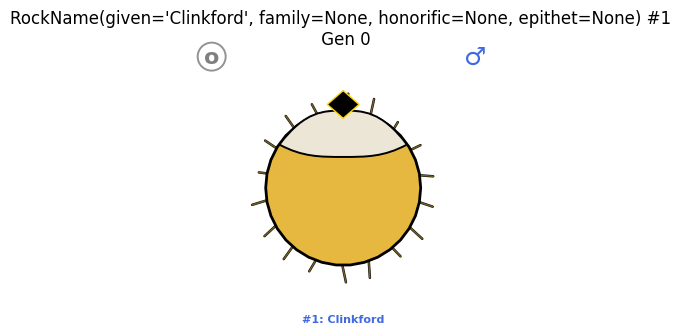

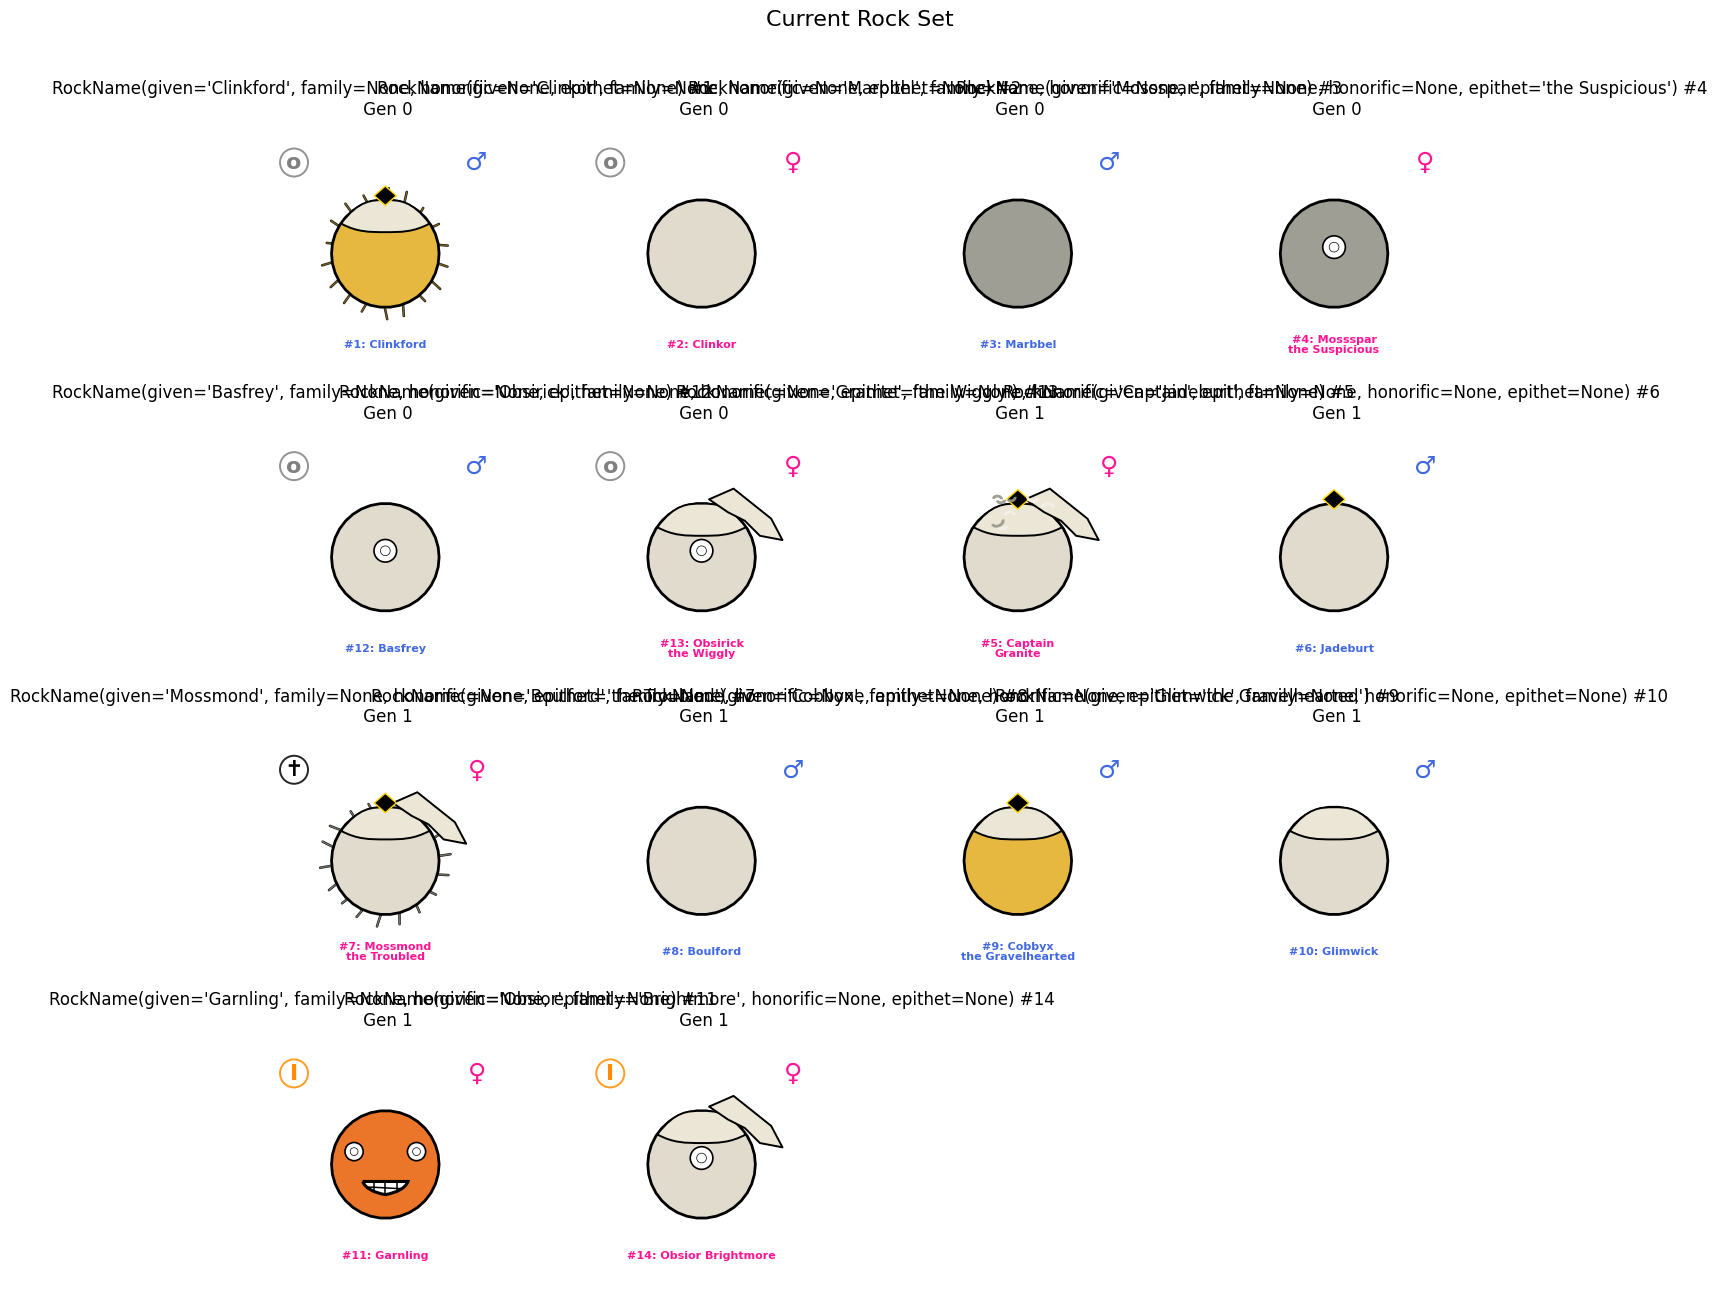

In [20]:
one_rock = next(iter(game.rocks.values()))

fig, ax = plt.subplots(figsize=(4, 4))
draw_rock(one_rock, ax=ax)
plt.show()

show_rock_grid(game.rocks, cols=4, title="Current Rock Set", sort_by_generation=True)
plt.show()

tree_fig = TreeDrawer(game=game, canvas_width=1200, canvas_height=800).draw()
tree_fig.show(config={"scrollZoom": True, "displayModeBar": True})

## Checkpoint 7B: Larger Multi-Generation Tree


Generation 1: queued 2 pair(s), created 7 child rock(s), total rocks=11
Generation 2: queued 2 pair(s), created 6 child rock(s), total rocks=17
Generation 3: queued 2 pair(s), created 5 child rock(s), total rocks=22
Generation 4: queued 2 pair(s), created 7 child rock(s), total rocks=29

=== Large game rocks ===
#1 Pebspar | male | gen 0 | bred | $0
#2 Geogem | female | gen 0 | bred | $0
#3 Dolfrey | male | gen 0 | bred | $0
#4 Jadelo Dustforge | female | gen 0 | bred | $0
#5 Micaspar | female | gen 1 | bred | $0
#6 Pebmore | male | gen 1 | bred | $0
#7 Tuffoid | male | gen 1 | bred | $0
#8 Slatemond Dustforge | male | gen 1 | bred | $0
#9 Garngem Dustforge | male | gen 1 | bred | $0
#10 Opallow Royalhelm | female | gen 1 | bred | $0
#11 Boulyx Dustforge | male | gen 1 | bred | $0
#12 Onnard Starmore | female | gen 2 | bred | $0
#13 Marbble | male | gen 2 | bred | $0
#14 Captain Grumbel Royalhelm | male | gen 2 | active | $5
#15 Garnbel Royalhelm | male | gen 2 | active | $3
#16 Garnbu

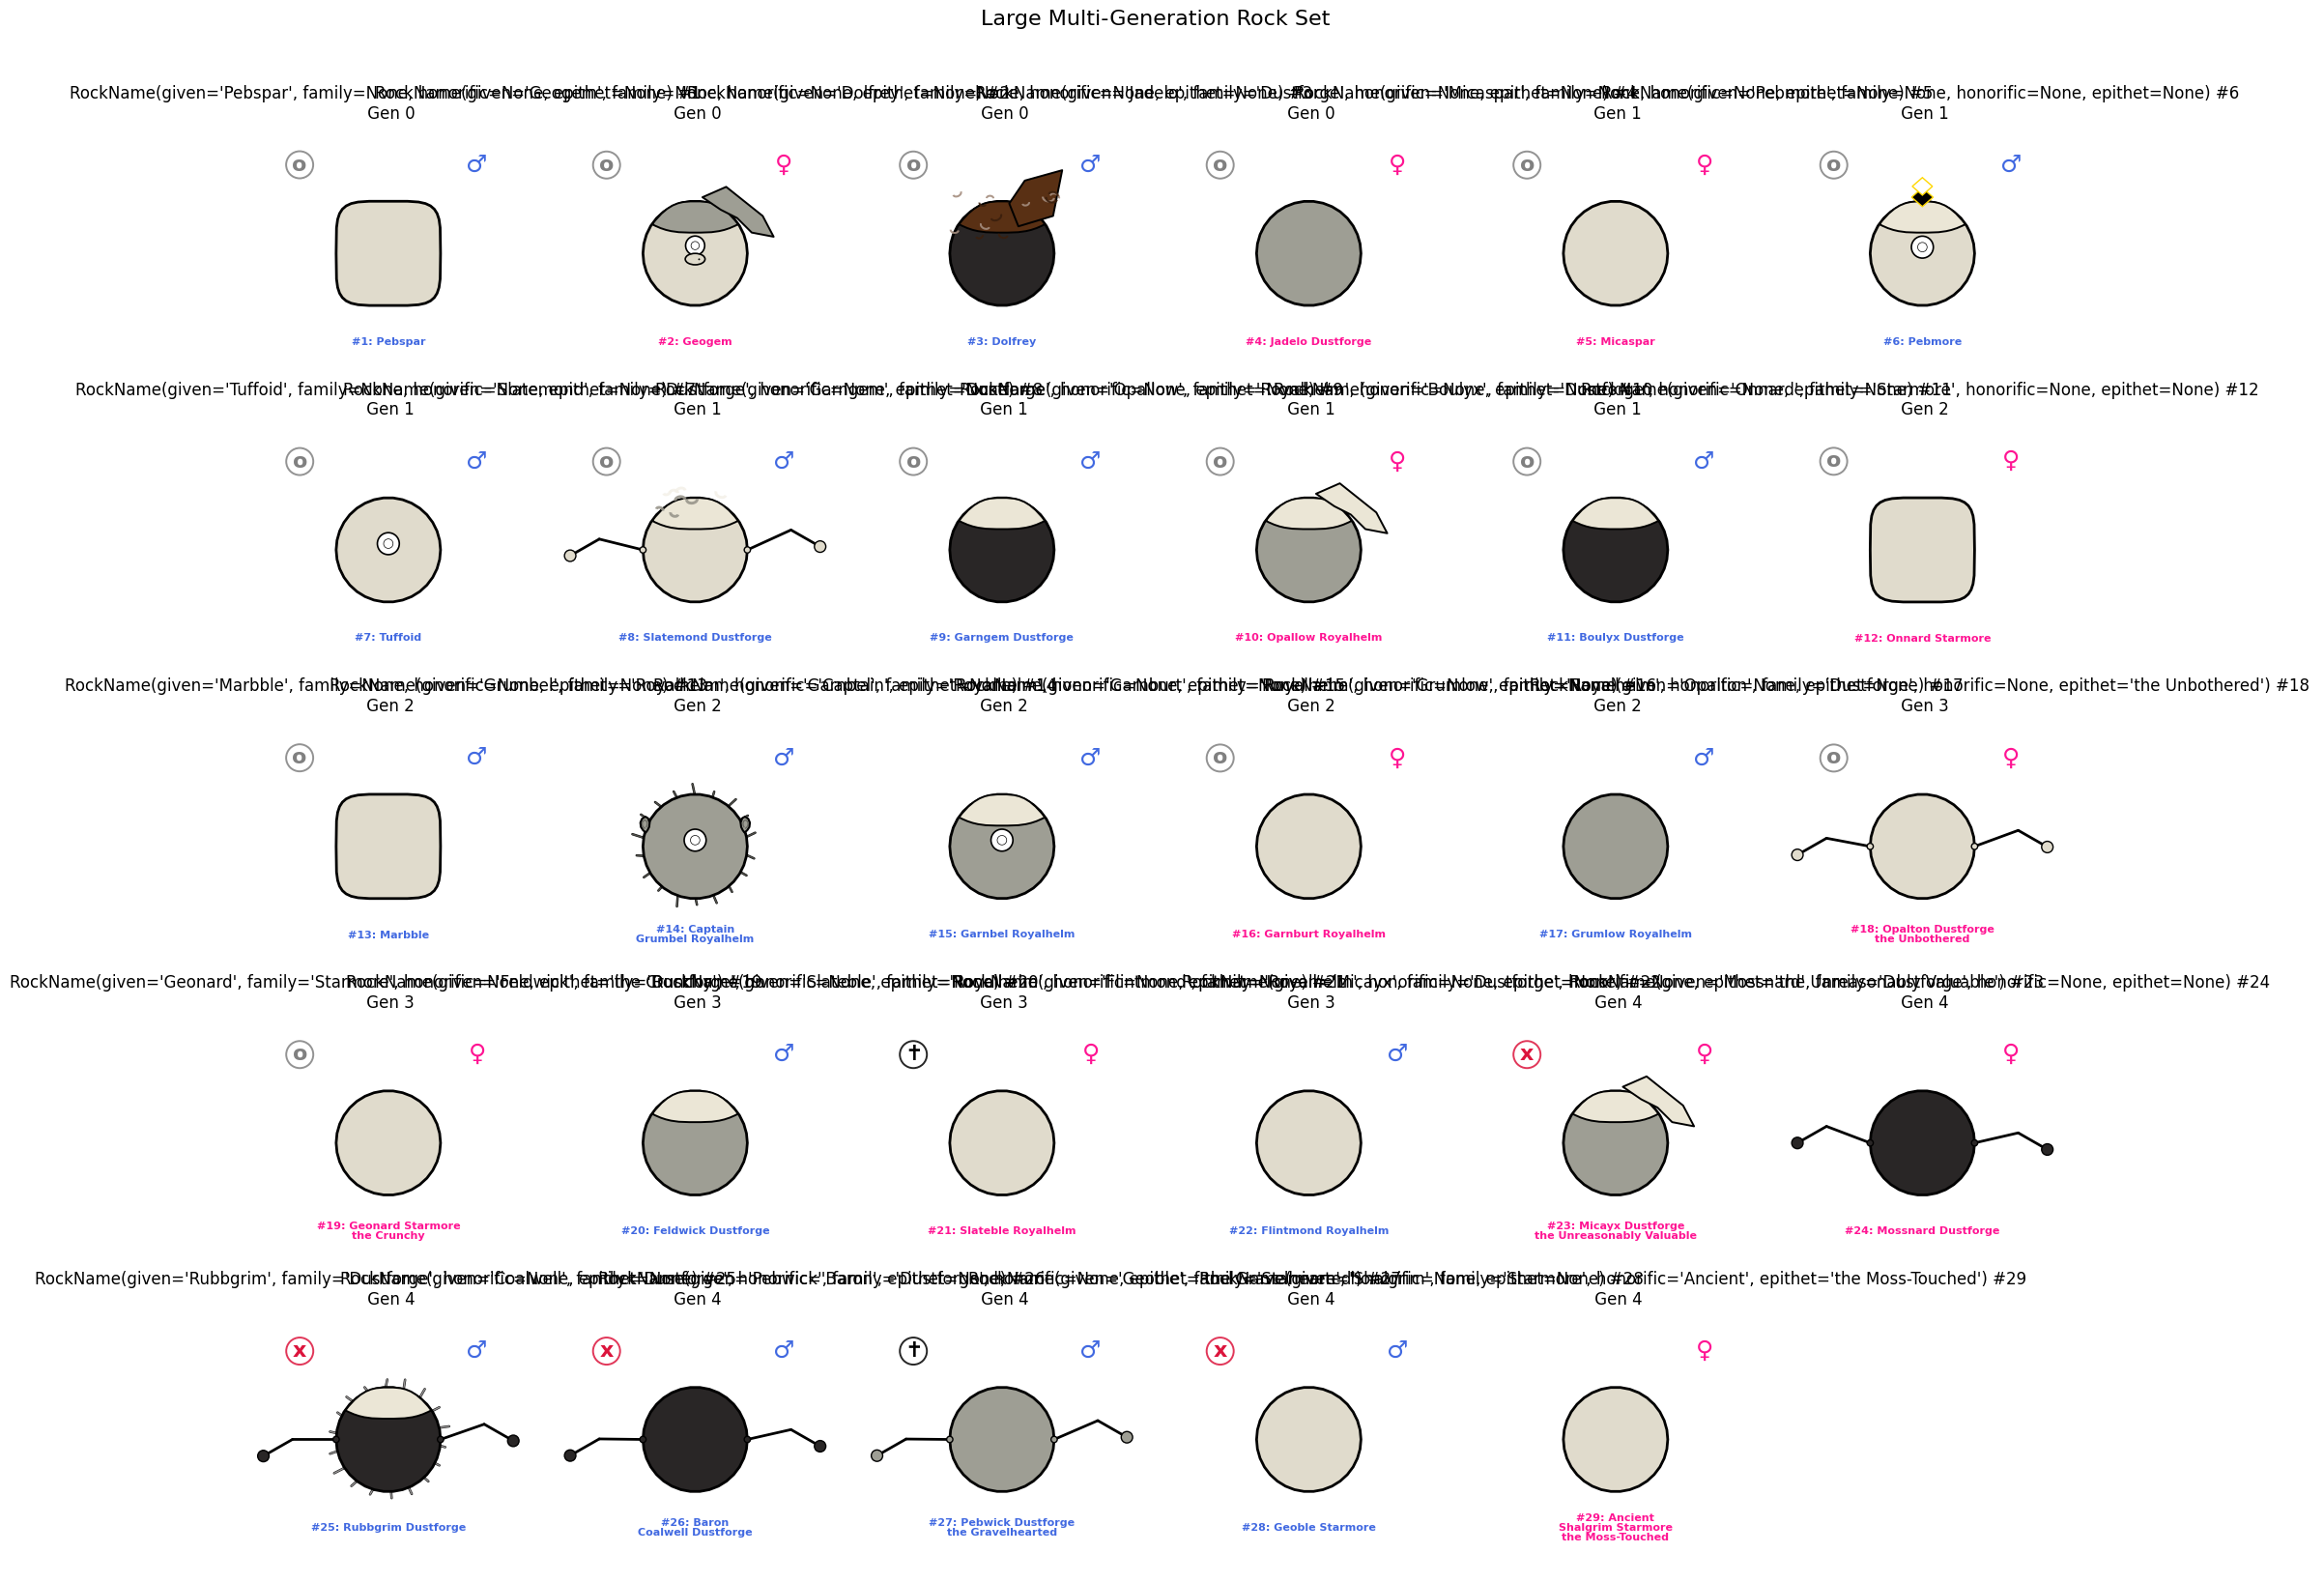

In [ ]:
large_game = GameMaster(seed=300, starting_money=120)

for step in range(7):
    queued = 0
    used_ids = set()
    active_males = [
        rock for rock in large_game.rocks.values()
        if rock.sex == genetics.Sex.MALE and rock.status == genetics.RockStatus.ACTIVE
    ]
    active_females = [
        rock for rock in large_game.rocks.values()
        if rock.sex == genetics.Sex.FEMALE and rock.status == genetics.RockStatus.ACTIVE
    ]

    for male in active_males:
        if queued >= large_game.max_pairs_per_generation or male.id in used_ids:
            continue
        for female in active_females:
            if female.id in used_ids:
                continue
            try:
                large_game.add_pair_to_queue(male.id, female.id)
            except ValueError:
                continue
            used_ids.update({male.id, female.id})
            queued += 1
            break

    if queued == 0:
        print(f"Generation step {step + 1}: no valid pairs left.")
        break

    new_children = large_game.advance_generation()
    print(
        f"Generation {large_game.generation}: queued {queued} pair(s), "
        f"created {len(new_children)} child rock(s), total rocks={len(large_game.rocks)}"
    )

list_rocks(large_game, "Large game rocks")
#show_rock_grid(
#    large_game.rocks,
#    cols=6,
#    title="Large Multi-Generation Rock Set",
#    sort_by_generation=True,
#)
plt.show()

large_tree_fig = TreeDrawer(game=large_game, canvas_width=1500, canvas_height=950).draw()
large_tree_fig.show(config={"scrollZoom": True, "displayModeBar": True})


## Checkpoint 8: Relationship Validation Smoke Check

In [22]:
first_child = children[0]
related_parent = game.get_rock(first_child.parent_ids[0])

try:
    game.add_pair_to_queue(related_parent.id, first_child.id)
except ValueError as exc:
    print("Relationship validation blocked breeding as expected:")
    print(exc)

Relationship validation blocked breeding as expected:
Invalid breeding pair: parent a is not breedable, but is: RockStatus.BRED
